In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import kagglehub

path = kagglehub.dataset_download("alessiocorrado99/animals10")
print("Downloaded to:", path)


data_dir = os.path.join(path, "raw-img") if os.path.isdir(os.path.join(path, "raw-img")) else path
print("Using data_dir:", data_dir)

classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print("Classes:", classes)
print("Num classes:", len(classes))



Using Colab cache for faster access to the 'animals10' dataset.
Downloaded to: /kaggle/input/animals10
Using data_dir: /kaggle/input/animals10/raw-img
Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Num classes: 10


Raw image: /kaggle/input/animals10/raw-img/pecora/OIP-3l8KAkAiOcJBbJ-68FCBNwHaE9.jpeg
Raw size: (300, 201) mode: RGB


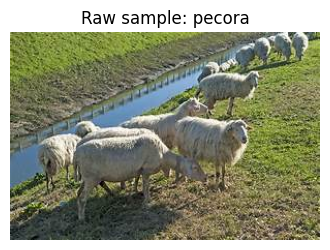

In [ ]:
cls = classes[7]
img_file = os.listdir(os.path.join(data_dir, cls))[0]
img_path = os.path.join(data_dir, cls, img_file)

img = Image.open(img_path)
print("Raw image:", img_path)
print("Raw size:", img.size, "mode:", img.mode)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Raw sample: {cls}")
plt.axis("off")
plt.show()


In [ ]:
batch_size = 64
img_height = 28
img_width  = 28

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


In [ ]:
model_28 = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(28, 28, 3)),

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes)
])

model_28.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model_28.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,418 (21.16 KB)

 Trainable params: 5,418 (21.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

history_28 = model_28.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 73s 54ms/step - accuracy: 0.1869 - loss: 2.2164 - val_accuracy: 0.2407 - val_loss: 2.1312
Epoch 2/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2432 - loss: 2.1156 - val_accuracy: 0.2653 - val_loss: 2.0610
Epoch 3/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2608 - loss: 2.0535 - val_accuracy: 0.2886 - val_loss: 2.0031
Epoch 4/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2779 - loss: 2.0035 - val_accuracy: 0.2995 - val_loss: 1.9564
Epoch 5/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3075 - loss: 1.9507 - val_accuracy: 0.3335 - val_loss: 1.8981
Epoch 6/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3303 - loss: 1.9011 - val_accuracy: 0.3494 - val_loss: 1.8696
Epoch 7/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3378 - loss: 1.8773 - val_accuracy: 0.3415 - val_loss: 1.8640
Epoch 8/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3500 - loss: 1.8496 - val_accuracy: 

## Deeper + Batch Normalization + Dropout

In [ ]:
model_28_bn = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(28, 28, 3)),

    layers.Conv2D(32, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(num_classes)
])

model_28_bn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
]

history_28_bn = model_28_bn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.2899 - loss: 2.0017 - val_accuracy: 0.1947 - val_loss: 2.5474
Epoch 2/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4442 - loss: 1.5979 - val_accuracy: 0.4277 - val_loss: 1.6949
Epoch 3/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4978 - loss: 1.4489 - val_accuracy: 0.2808 - val_loss: 2.5806
Epoch 4/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5210 - loss: 1.3860 - val_accuracy: 0.3266 - val_loss: 2.1140


#Input resolution: From 28×28 to 128×128
The input resolution was increased to 128×128 pixels, allowing the network to access richer spatial information.

In [ ]:
batch_size = 32
img_height = 128
img_width  = 128
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("class_names:", class_names)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
class_names: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


dtype: <dtype: 'float32'> min/max: 0.0 255.0


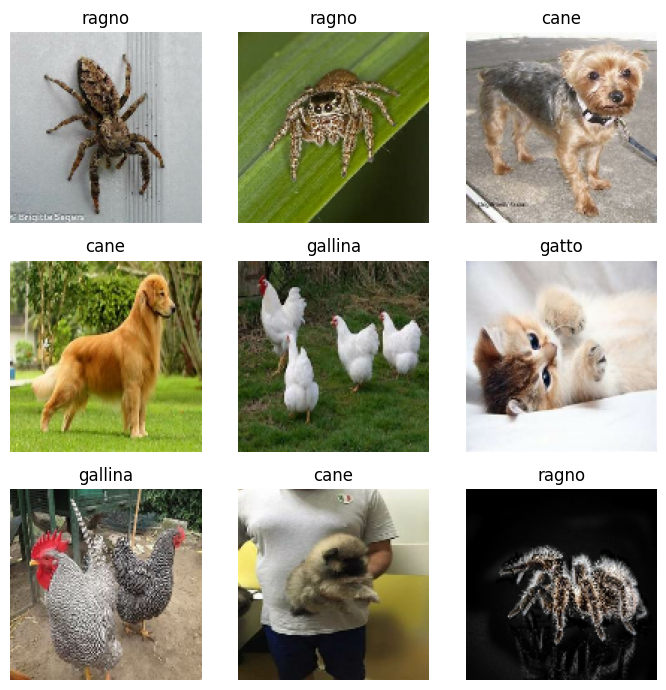

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

plt.figure(figsize=(7,7))
for images, labels in train_ds.take(1):
    print("dtype:", images.dtype, "min/max:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))

    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        img = images[i].numpy()
        if img.max() <= 1.0:
            plt.imshow(img)
        else:
            plt.imshow(img.astype("uint8"))

        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
baseline = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes)
])

baseline.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

baseline.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,154 (8.10 MB)

 Trainable params: 2,122,154 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10
hist_base = baseline.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.3339 - loss: 1.8806 - val_accuracy: 0.5278 - val_loss: 1.3610
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5795 - loss: 1.2447 - val_accuracy: 0.6216 - val_loss: 1.1215
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6983 - loss: 0.9110 - val_accuracy: 0.6350 - val_loss: 1.0842
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7806 - loss: 0.6636 - val_accuracy: 0.6497 - val_loss: 1.0689
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8493 - loss: 0.4490 - val_accuracy: 0.6560 - val_loss: 1.2018
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9139 - loss: 0.2636 - val_accuracy: 0.6353 - val_loss: 1.4868
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9502 - loss: 0.1544 - val_accuracy: 0.6588 - val_loss: 1.5641
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9645 - loss: 0.1080 - val_acc

## Dropout + EarlyStopping

In [ ]:
baseline_128 = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes)
])

baseline_128.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
]

hist_128 = baseline_128.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.2746 - loss: 2.0476 - val_accuracy: 0.4840 - val_loss: 1.4948
Epoch 2/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4576 - loss: 1.5658 - val_accuracy: 0.5528 - val_loss: 1.3640
Epoch 3/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5320 - loss: 1.3517 - val_accuracy: 0.5910 - val_loss: 1.1920
Epoch 4/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5918 - loss: 1.1868 - val_accuracy: 0.6256 - val_loss: 1.1084
Epoch 5/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6365 - loss: 1.0637 - val_accuracy: 0.6399 - val_loss: 1.0695
Epoch 6/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6718 - loss: 0.9521 - val_accuracy: 0.6533 - val_loss: 1.0320
Epoch 7/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7086 - loss: 0.8431 - val_accuracy: 0.6447 - val_loss: 1.0394
Epoch 8/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7337 - loss: 0.7632 - val_acc

## Add ReduceLROnPlateau

In [ ]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

model_best = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes)
])

model_best.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
]

history_best = model_best.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)
best_idx = int(np.argmax(history_best.history["val_accuracy"]))

train_acc = history_best.history["accuracy"][best_idx]
train_loss = history_best.history["loss"][best_idx]
val_acc = history_best.history["val_accuracy"][best_idx]
val_loss = history_best.history["val_loss"][best_idx]

print("\n=== FINAL RESULTS (use these for the blanks) ===")
print(f"Training Accuracy and Loss of the best model: {train_acc:.4f} {train_loss:.4f}")
print(f"Validation Accuracy and Loss of the best model: {val_acc:.4f} {val_loss:.4f}")

Epoch 1/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.2728 - loss: 2.0448 - val_accuracy: 0.4649 - val_loss: 1.5554 - learning_rate: 0.0010
Epoch 2/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4534 - loss: 1.5769 - val_accuracy: 0.5585 - val_loss: 1.3209 - learning_rate: 0.0010
Epoch 3/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5352 - loss: 1.3546 - val_accuracy: 0.5950 - val_loss: 1.1654 - learning_rate: 0.0010
Epoch 4/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5834 - loss: 1.2000 - val_accuracy: 0.6397 - val_loss: 1.0774 - learning_rate: 0.0010
Epoch 5/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6281 - loss: 1.0755 - val_accuracy: 0.6394 - val_loss: 1.0549 - learning_rate: 0.0010
Epoch 6/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6700 - loss: 0.9520 - val_accuracy: 0.6615 - val_loss: 1.0033 - learning_rate: 0.0010
Epoch 7/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6974 - loss: 0

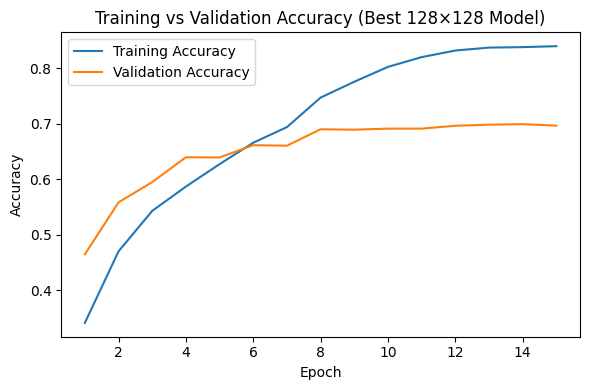

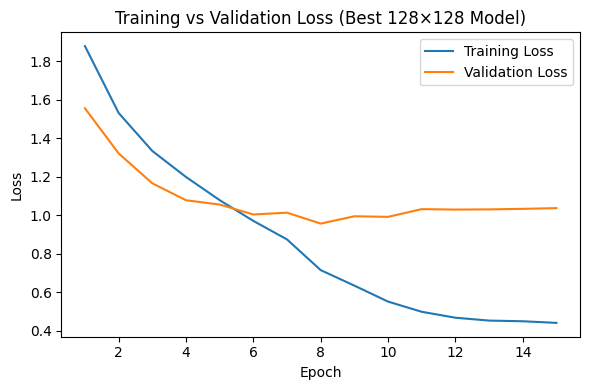

In [ ]:
import matplotlib.pyplot as plt

acc = history_best.history["accuracy"]
val_acc = history_best.history["val_accuracy"]
loss = history_best.history["loss"]
val_loss = history_best.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Best 128×128 Model)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Best 128×128 Model)")
plt.legend()
plt.tight_layout()
plt.show()
